In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
import pandas as pd

# -----------------------------
# STATE
# -----------------------------

class AgentState(TypedDict):
    file_uploaded: pd.DataFrame
    dataset_clean: bool
    contains_text: bool
    user_goal: str


# -----------------------------
# SUPERVISOR NODE
# MUST RETURN DICT
# -----------------------------

def supervisor_agent(state: AgentState):

    print("Supervisor analyzing workflow...")

    return state


# -----------------------------
# ROUTER FUNCTION
# RETURNS NODE NAME
# -----------------------------

def supervisor_router(state: AgentState):

    # No file
    if not state["file_uploaded"]:
        print('please upload file')
        return END

    # Only charts requested
    if "chart" in state["user_goal"].lower():
        return "visualization_agent"

    # Text dataset
    if state["contains_text"]:
        return "nlp_agent"

    # Needs cleaning
    if not state["dataset_clean"]:
        return "cleaning_agent"

    # Default
    return "eda_agent"


# -----------------------------
# AGENTS
# -----------------------------

def cleaning_agent(state: AgentState):

    print("Cleaning dataset...")

    state["dataset_clean"] = True

    return state


def eda_agent(state: AgentState):

    print("Running EDA...")

    return state


def visualization_agent(state: AgentState):

    print("Generating charts...")

    return state


def nlp_agent(state: AgentState):

    print("Analyzing text...")

    return state


def report_agent(state: AgentState):

    print("Generating report...")

    return state


# -----------------------------
# BUILD GRAPH
# -----------------------------

graph = StateGraph(AgentState)

# Nodes
graph.add_node("supervisor", supervisor_agent)
graph.add_node("cleaning_agent", cleaning_agent)
graph.add_node("eda_agent", eda_agent)
graph.add_node("visualization_agent", visualization_agent)
graph.add_node("nlp_agent", nlp_agent)
graph.add_node("report_agent", report_agent)

# Entry
graph.set_entry_point("supervisor")

# CONDITIONAL EDGES
graph.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {
        "cleaning_agent": "cleaning_agent",
        "eda_agent": "eda_agent",
        "visualization_agent": "visualization_agent",
        "nlp_agent": "nlp_agent",
        END: END
    }
)

# Sequential flow
graph.add_edge("cleaning_agent", "eda_agent")
graph.add_edge("eda_agent", "visualization_agent")
graph.add_edge("visualization_agent", "report_agent")
graph.add_edge("nlp_agent", "report_agent")

# Finish
graph.add_edge("report_agent", END)

# Compile
app = graph.compile()


# -----------------------------
# RUN
# -----------------------------

initial_state = {
    "file_uploaded": True,
    "dataset_clean": False,
    "contains_text": False,
    "user_goal": "analyze sales dataset"
}

result = app.invoke(initial_state)

print(result)

Supervisor analyzing workflow...
Cleaning dataset...
Running EDA...
Generating charts...
Generating report...
{'file_uploaded': True, 'dataset_clean': True, 'contains_text': False, 'user_goal': 'analyze sales dataset'}


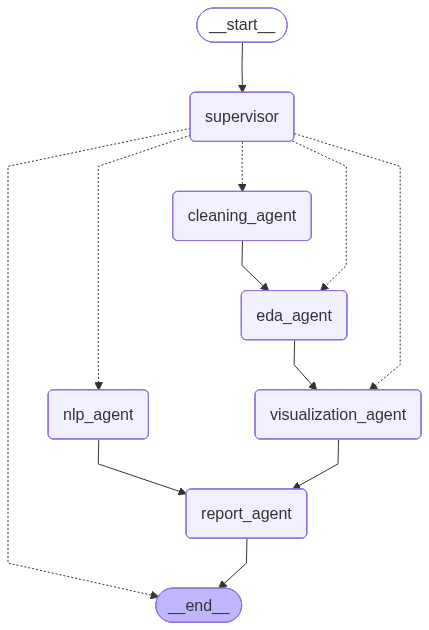

In [9]:
app

In [88]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field

llm = ChatGroq(model='openai/gpt-oss-120b', temperature=1)

In [89]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('tips')

In [95]:
class visual(BaseModel):

    chart_type: str = Field(description='which type of chart you want to create.')
    X_axis: str = Field(description='x axis column')
    Y_axis: str = Field(description='y axis column')

visual_llm  = llm.with_structured_output(visual)

In [96]:

prompt = f"""
Dataset columns:
{df.columns.tolist()}


"""

response = visual_llm.invoke(prompt)

BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is required, but model did not call a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': 'I see the columns from the classic “tips” dataset:\n\n- **total_bill**\n- **tip**\n- **sex**\n- **smoker**\n- **day**\n- **time**\n- **size**\n\nWhat would you like to explore or visualize with this data? For example, you could:\n\n- Compare **tip** vs. **total_bill** (scatter plot)  \n- See the distribution of **total_bill** by **day** (box plot)  \n- Look at average **tip** by **sex** or **smoker** status (bar chart)  \n- Examine how **size** of the party relates to **total_bill** (line or scatter)\n\nLet me know which variables you’d like on the x‑ and y‑axes (and the type of chart you prefer), and I can generate the visualization for you.'}}

In [ ]:
response.content

"Below are a few “go‑to” visualisations that make the most of the **tips** data set (the classic seaborn\u202f`tips` data).  \nPick the one that matches the question you want to answer; each suggestion lists a clear X‑axis, Y‑axis and the chart type that will show the pattern most effectively.\n\n| Goal / Question | Best chart type | X‑axis | Y‑axis | Quick notes / how to read it |\n|-----------------|----------------|--------|--------|------------------------------|\n| **How does the tip amount grow with the bill?** (numeric\u202f↔\u202fnumeric) | **Scatter plot** (optionally add a regression line) | `total_bill` (continuous) | `tip` (continuous) | Points show each order; a fitted line (e.g., `sns.regplot`) highlights the overall tip‑% trend. Add `hue='sex'` or `hue='smoker'` to see gender or smoking status differences. |\n| **What is the average tip (or tip\u202f%) per day of the week?** (categorical\u202f↔\u202fnumeric) | **Bar chart** (mean tip) or **Box‑plot** (distribution) | `da